In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
city = "Ivano-Frankivsk"

months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

rainfall = pd.Series(
    [45, 42, 45, 60, 90, 105, 110, 95, 60, 50, 52, 48],
    index=months
)

rainfall

January       45
February      42
March         45
April         60
May           90
June         105
July         110
August        95
September     60
October       50
November      52
December      48
dtype: int64

## Завдання 1. Класифікація змінних за шкалою вимірювання

### 1. Місто

Змінна "місто" належить до **номінальної шкали вимірювання**.

Назви міст є категоріями, між якими немає природного порядку. Наприклад, не можна сказати, що Івано-Франківськ "більший" або "менший" за Київ у сенсі значення цієї змінної. Тому для міста не мають змісту арифметичні операції та обчислення середнього або медіани.

Коректною мірою положення для номінальної змінної є **мода** — найчастіше значення.

### 2. Номер місяця

Змінну "номер місяця" можна обґрунтовано розглядати як **порядкову шкалу**.

Місяці мають природний порядок: 1, 2, 3, ..., 12. Проте не існує природного "нульового місяця", який означав би відсутність місяця. Тому номер місяця не є відносною шкалою.

Водночас календарні проміжки між сусідніми місяцями є приблизно рівними, тому можливий аргумент на користь інтервальної шкали. У цій роботі номер місяця класифікуємо як **порядкову змінну**.

Для порядкової змінної коректною є **медіана**, а також **мода**.

### 3. Кількість опадів

Змінна "кількість опадів (мм)" належить до **відносної шкали вимірювання**.

Для неї існує природний нуль: 0 мм означає повну відсутність опадів. Також можна змістовно порівнювати відношення значень: наприклад, 100 мм опадів у два рази більше, ніж 50 мм.

Тому для кількості опадів коректно використовувати всі три міри положення: **середнє, медіану та моду**.

### Підсумок

| Змінна | Шкала вимірювання | Коректні міри положення |
|---|---|---|
| Місто | Номінальна | Мода |
| Номер місяця | Порядкова | Медіана, мода |
| Кількість опадів (мм) | Відносна | Середнє, медіана, мода |

In [21]:
variation_series = np.sort(rainfall.values)

print("Variation series:")
print(variation_series)

Variation series:
[ 42  45  45  48  50  52  60  60  90  95 105 110]


In [22]:
bins = [41, 59, 76, 93, 110]

labels = [
    "42-59",
    "60-76",
    "77-93",
    "94-110"
]

groups = pd.cut(
    rainfall,
    bins=bins,
    labels=labels
)

groups

January       42-59
February      42-59
March         42-59
April         60-76
May           77-93
June         94-110
July         94-110
August       94-110
September     60-76
October       42-59
November      42-59
December      42-59
dtype: category
Categories (4, str): ['42-59' < '60-76' < '77-93' < '94-110']

In [23]:
freq = groups.value_counts().sort_index()

rel = freq / len(rainfall) * 100

cum = freq.cumsum()

frequency_table = pd.DataFrame({
    "Absolute frequency": freq,
    "Relative frequency (%)": rel.round(1),
    "Cumulative frequency": cum
})

frequency_table

,Absolute frequency,Relative frequency (%),Cumulative frequency
42-59,6,50.0,6
60-76,2,16.7,8
77-93,1,8.3,9
94-110,3,25.0,12


### Частка місяців до межі третього інтервалу

Третій інтервал має верхню межу 93 мм. Накопичена частота на цій межі становить 9 із 12 місяців.

9 / 12 × 100% = 75%.

Отже, **75% місяців року мають кількість опадів не більшу за 93 мм**.

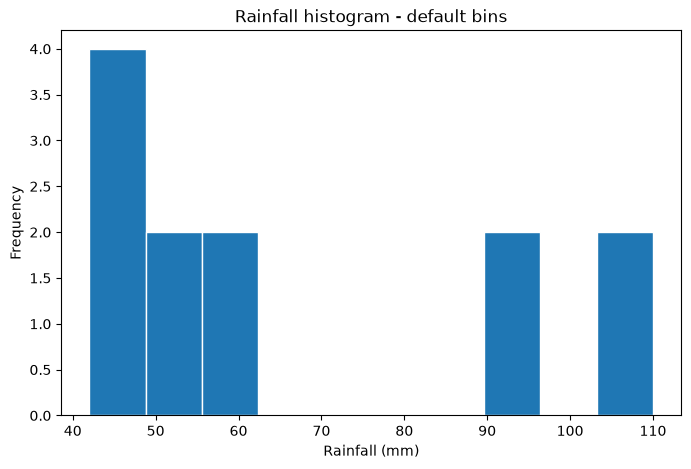

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(rainfall.values, edgecolor="white")

plt.title("Rainfall histogram - default bins")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

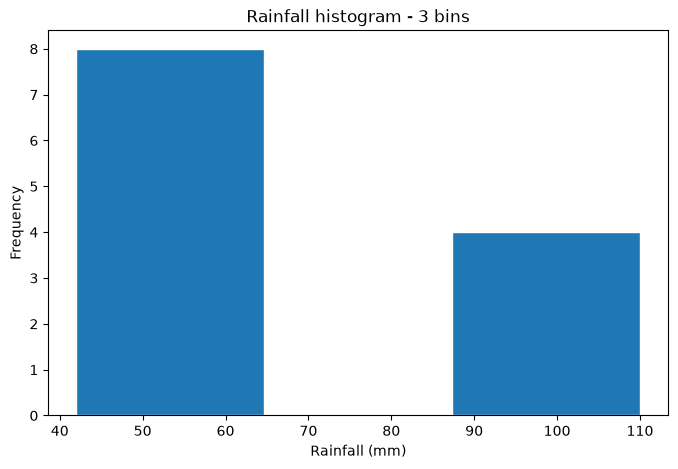

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(rainfall.values, bins=3, edgecolor="white")

plt.title("Rainfall histogram - 3 bins")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

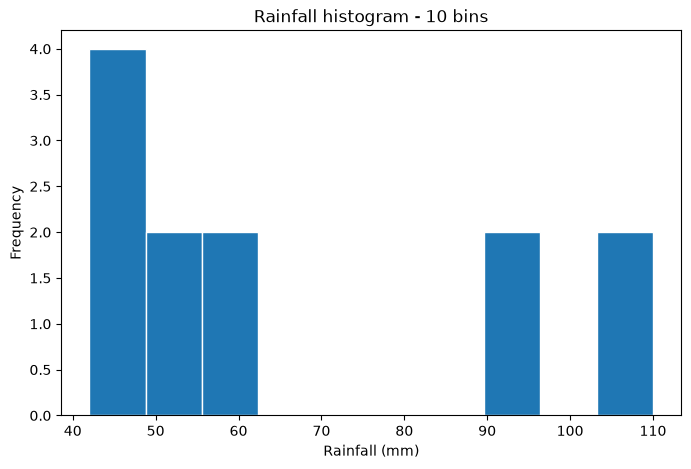

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(rainfall.values, bins=10, edgecolor="white")

plt.title("Rainfall histogram - 10 bins")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

In [27]:
n = len(rainfall)

sqrt_rule = np.sqrt(n)
sturges_rule = 1 + np.log2(n)

print("Number of observations:", n)
print("Square root rule:", round(sqrt_rule, 2))
print("Sturges rule:", round(sturges_rule, 2))

Number of observations: 12
Square root rule: 3.46
Sturges rule: 4.58


### Порівняння гістограм

Для 12 спостережень правило √n дає приблизно 3,46 інтервали, тобто близько 3–4 інтервалів. Правило Стерджеса дає приблизно 4,58, тобто близько 5 інтервалів.

Гістограма з 3 інтервалами найкраще підходить для такого малого набору даних, оскільки вона показує загальну форму розподілу без надмірного подрібнення.

Гістограма з 10 інтервалами є занадто деталізованою для 12 спостережень, тому окремі стовпці можуть відображати випадкові коливання, а не загальну закономірність.

Отже, серед трьох побудованих гістограм для цього набору найдоцільнішою є гістограма з **3 bins**.

In [28]:
mean_value = rainfall.mean()
median_value = rainfall.median()
mode_value = rainfall.mode()

print("Mean:", round(mean_value, 2))
print("Median:", median_value)
print("Mode:")
print(mode_value)

Mean: 66.83
Median: 56.0
Mode:
0    45
1    60
dtype: int64


In [29]:
q1 = rainfall.quantile(0.25)
q3 = rainfall.quantile(0.75)

print("Q1:", q1)
print("Q3:", q3)

Q1: 47.25
Q3: 91.25


In [30]:
statistics = pd.DataFrame({
    "Measure": [
        "Mean",
        "Median",
        "Mode 1",
        "Mode 2",
        "Q1",
        "Q3"
    ],
    "Value": [
        mean_value,
        median_value,
        mode_value.iloc[0],
        mode_value.iloc[1],
        q1,
        q3
    ]
})

statistics

,Measure,Value
0,Mean,66.833333
1,Median,56.000000
2,Mode 1,45.000000
3,Mode 2,60.000000
4,Q1,47.250000
5,Q3,91.250000


### Порівняння середнього та медіани

Середня кількість опадів становить приблизно 66,83 мм, а медіана — 56 мм. Різниця між ними становить приблизно 10,83 мм, тому середнє помітно більше за медіану.

Це пов'язано з асиметрією розподілу. У літні місяці кількість опадів значно вища: 90, 95, 105 та 110 мм. Ці великі значення підвищують арифметичне середнє.

Більшість інших значень знаходиться приблизно в межах 42–60 мм. Отже, розподіл опадів протягом року має правосторонню асиметрію: кілька значно вологіших місяців зміщують середнє в бік більших значень.

## Завдання 5. Зв'язок зі шкалою вимірювання

Кількість атмосферних опадів у міліметрах належить до відносної шкали вимірювання. Вона має природний нуль: 0 мм означає повну відсутність опадів. Також можна змістовно порівнювати відношення значень, наприклад 100 мм опадів у два рази більше, ніж 50 мм.

Тому для кількості опадів коректно використовувати всі три міри положення: середнє, медіану та моду.

Середнє показує середню кількість опадів за місяць, медіана показує центральне значення впорядкованого ряду, а мода показує значення, які зустрічаються найчастіше.

На відміну від цього, змінна "місто" є номінальною. Назви міст не мають природного числового порядку або числової відстані між ними. Навіть якщо умовно закодувати міста числами, наприклад Київ = 1, Львів = 2, Одеса = 3, ці числа будуть лише кодами категорій. Їхнє середнє не матиме змістовної інтерпретації.

Тому для змінної "місто" з трьох розглянутих мір положення коректною є лише мода.

## Додаткові питання

### 1. Чи можна використовувати середнє арифметичне для змінної "місто"?

Ні. Змінна "місто" є номінальною, тобто її значеннями є категорії без числового порядку. Навіть якщо кожному місту присвоїти число, наприклад 1, 2 або 3, це будуть лише умовні коди. Середнє таких кодів не матиме змістовної інтерпретації. Для номінальної змінної коректною мірою положення є мода.

### 2. Чому номер місяця можна класифікувати неоднозначно?

Номер місяця має природний порядок від 1 до 12, тому його можна розглядати як порядкову змінну. Водночас проміжки між сусідніми місяцями в календарі є рівними, що дає аргумент на користь інтервальної шкали. Проте природного нульового місяця не існує. Тому класифікація номера місяця не є однозначною.

### 3. Чому для кількості опадів потрібна гістограма?

Кількість опадів є кількісною змінною, а значення набору мають різні величини. Стовпчикова діаграма за окремими значеннями була б малозмістовною для такого набору. Гістограма об'єднує близькі значення в інтервали та показує частоту потрапляння спостережень у кожен інтервал. Тому вона краще демонструє форму розподілу опадів.

### 4. Що означає накопичена частота на межі третього інтервалу?

Третій інтервал закінчується на значенні 93 мм. Накопичена частота на цій межі дорівнює 9. Це означає, що 9 із 12 місяців мали кількість опадів не більше 93 мм.

9 / 12 × 100% = 75%.

Отже, **75% місяців року мали кількість опадів не більше 93 мм**.